In [1]:
# new test code for HRS unification labels

import requests
import zipfile
import io
import os
import pandas as pd
import matplotlib.pyplot as plt
import tabulate as tabulate
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Define the base URL
base_url = 'https://www.cftc.gov/files/dea/history/com_disagg_txt_'

# Define the years to download and extract
years = range(2010, 2027)

# Create an empty list to hold the data frames for each year
df_list = []

# Define a function to standardize commodity names
def standardize_commodity_names(df):
    df['Market_and_Exchange_Names'] = df['Market_and_Exchange_Names'].replace({
        'WHEAT-HRSpring - MINNEAPOLIS GRAIN EXCHANGE': 'WHEAT-HRSpring',
        'WHEAT-HRSpring - MIAX FUTURES EXCHANGE': 'WHEAT-HRSpring'
    })
    return df

# Define the list of commodities to filter
commodities = ['CORN - CHICAGO BOARD OF TRADE',
               'WHEAT-SRW - CHICAGO BOARD OF TRADE',
               'WHEAT-HRSpring',  # Standardized name
               'WHEAT-HRW - CHICAGO BOARD OF TRADE',
               'CANOLA - ICE FUTURES U.S.',
               'SOYBEANS - CHICAGO BOARD OF TRADE',
               'SOYBEAN OIL - CHICAGO BOARD OF TRADE',
               'CRUDE OIL, LIGHT SWEET-WTI - ICE FUTURES EUROPE']

# Loop through the years and process the data
for year in years:
    # Construct the URL for the zip file for the given year
    url = base_url + str(year) + '.zip'

    # Download the zip file
    response = requests.get(url)
    if response.status_code == 200:
        with io.BytesIO(response.content) as f:
            with zipfile.ZipFile(f) as zip_ref:
                # Extract the zip file
                extract_path = 'com_disagg_txt_' + str(year)
                zip_ref.extractall(extract_path)

                # Read the CSV file
                file_path = os.path.join(extract_path, 'c_year.txt')
                df = pd.read_csv(file_path, delimiter=',', header=0)

                # Standardize commodity names before filtering
                df = standardize_commodity_names(df)

                # Filter for selected commodities
                df = df[df['Market_and_Exchange_Names'].isin(commodities)]

                # Calculate the net managed money positions for each commodity
                df['Net_Managed_Money_Positions'] = pd.to_numeric(df['M_Money_Positions_Long_All'], errors='coerce') - \
                                                     pd.to_numeric(df['M_Money_Positions_Short_All'], errors='coerce')
                
                # Convert date format
                df['As_of_Date_In_Form_YYMMDD'] = pd.to_datetime(df['As_of_Date_In_Form_YYMMDD'], format='%y%m%d', errors='coerce')

                # Extract day, month, and year from the date column
                df['Day'] = df['As_of_Date_In_Form_YYMMDD'].dt.day
                df['Month'] = df['As_of_Date_In_Form_YYMMDD'].dt.month
                df['Year'] = df['As_of_Date_In_Form_YYMMDD'].dt.year

                # Append the data frame to the list
                df_list.append(df)
    else:
        print(f'Failed to download Commitment of Traders report for year {year}')



In [2]:
# Concatenate all data frames into a single data frame
combined_df = pd.concat(df_list)

# Group by commodity, exchange, year, and month and calculate the net managed money positions
grouped_df = combined_df.groupby(['Market_and_Exchange_Names', 'Year', 'Month', 'Day', 'Report_Date_as_YYYY-MM-DD'])['Net_Managed_Money_Positions'].sum().reset_index()

# Create an empty dictionary to store summary information
summary_dict = {}


In [3]:
# Create a list of commodities & calc parameters around them
commodity_list = ['CORN - CHICAGO BOARD OF TRADE',
                  'WHEAT-SRW - CHICAGO BOARD OF TRADE',
                  #'WHEAT-HRSpring - MINNEAPOLIS GRAIN EXCHANGE',
                  'WHEAT-HRSpring'
                  'WHEAT-HRW - CHICAGO BOARD OF TRADE',
                  'CANOLA - ICE FUTURES U.S.',
                  'SOYBEANS - CHICAGO BOARD OF TRADE',
                  'SOYBEAN OIL - CHICAGO BOARD OF TRADE',
                  'CRUDE OIL, LIGHT SWEET-WTI - ICE FUTURES EUROPE']

# Your code for visualizing data can go here, using the 'grouped_df' DataFrame

# Display your plots using plt.show() when you're ready to visualize the data
plt.show()

# create a dictionary of commodity names with their shorter names
commodity_dict = {'CORN - CHICAGO BOARD OF TRADE': 'CORN',
                  'WHEAT-SRW - CHICAGO BOARD OF TRADE': 'SRW',
                  #'WHEAT-HRSpring - MINNEAPOLIS GRAIN EXCHANGE': 'HRS',
                  'WHEAT-HRSpring': 'HRS',
                  'WHEAT-HRW - CHICAGO BOARD OF TRADE': 'HRW',  # Add the shorter name here
                  'CANOLA - ICE FUTURES U.S.': 'Canola',
                  'SOYBEANS - CHICAGO BOARD OF TRADE': 'Soybean',
                  'SOYBEAN OIL - CHICAGO BOARD OF TRADE': 'Soyoil',
                  'CRUDE OIL, LIGHT SWEET-WTI - ICE FUTURES EUROPE':'Crude'}


# create a list of commodities & calc parameters around them
commodity_list = list(commodity_dict.keys())
# convert the date column to a pandas datetime format
df['Report_Date_as_YYYY-MM-DD'] = pd.to_datetime(df['Report_Date_as_YYYY-MM-DD'])

# get the most recent date in the data
most_recent_date = df['Report_Date_as_YYYY-MM-DD'].max()

# filter the original data to include only the most recent date
filtered_df = df[df['Report_Date_as_YYYY-MM-DD'] == most_recent_date]

# group the filtered data by commodity
grouped_df = filtered_df.groupby('Market_and_Exchange_Names')

# loop over each commodity group and print the relevant information
for name, group in grouped_df:
    commodity = commodity_dict[name]
    print("Commodity:", commodity)
    print("Date:", most_recent_date.strftime("%Y-%m-%d"))
    print("Open Interest:", f"{group['Open_Interest_All'].iloc[-1]:,}")
    print("Net Managed Money Position:", f"{group['Net_Managed_Money_Positions'].iloc[-1]:,}")

    # compute MM Net as % of total OI
    mm_net_pct_of_tot_oi = abs(group['Net_Managed_Money_Positions'].iloc[-1] / group['Open_Interest_All'].iloc[-1] * 100)
    print("MM Net % of Total OI:", f"{mm_net_pct_of_tot_oi:.2f}%")

    #print("MM Short % of OI:", f"{group['Pct_of_OI_M_Money_Short_Other'].iloc[-1]:.2f}%")
    #print("MM Long % of OI:", f"{group['Pct_of_OI_M_Money_Long_Other'].iloc[-1]:.2f}%")
    print()


Commodity: Canola
Date: 2026-06-02
Open Interest: 375,856
Net Managed Money Position: 61,636
MM Net % of Total OI: 16.40%

Commodity: CORN
Date: 2026-06-02
Open Interest: 2,454,804
Net Managed Money Position: 115,082
MM Net % of Total OI: 4.69%

Commodity: Crude
Date: 2026-06-02
Open Interest: 1,099,557
Net Managed Money Position: -20,566
MM Net % of Total OI: 1.87%

Commodity: Soyoil
Date: 2026-06-02
Open Interest: 879,979
Net Managed Money Position: 156,433
MM Net % of Total OI: 17.78%

Commodity: Soybean
Date: 2026-06-02
Open Interest: 1,293,079
Net Managed Money Position: 156,050
MM Net % of Total OI: 12.07%

Commodity: HRS
Date: 2026-06-02
Open Interest: 94,533
Net Managed Money Position: 18,356
MM Net % of Total OI: 19.42%

Commodity: HRW
Date: 2026-06-02
Open Interest: 346,354
Net Managed Money Position: 13,477
MM Net % of Total OI: 3.89%

Commodity: SRW
Date: 2026-06-02
Open Interest: 580,385
Net Managed Money Position: -57,871
MM Net % of Total OI: 9.97%



In [4]:
# Tabulating top long/short positions by commodity 
from tabulate import tabulate as tabulate_function
import pandas as pd

# Filter the DataFrame based on the commodities in your original code
commodities = ['CORN - CHICAGO BOARD OF TRADE',
               'WHEAT-SRW - CHICAGO BOARD OF TRADE',
               #'WHEAT-HRSpring - MINNEAPOLIS GRAIN EXCHANGE',
               'WHEAT-HRSpring',
               'WHEAT-HRW - CHICAGO BOARD OF TRADE',
               'CANOLA - ICE FUTURES U.S.',
               'SOYBEANS - CHICAGO BOARD OF TRADE',
               'SOYBEAN OIL - CHICAGO BOARD OF TRADE',
               'CRUDE OIL, LIGHT SWEET-WTI - ICE FUTURES EUROPE']

# Create an empty DataFrame to store the results
results_df = pd.DataFrame()

for commodity in commodities:
    long_data = []
    short_data = []

    for year in years:
        # Filter the DataFrame for the current year and commodity
        filtered_df = combined_df[(combined_df['Year'] == year) & (combined_df['Market_and_Exchange_Names'] == commodity)]

        if not filtered_df.empty:
            # Sort the filtered DataFrame by 'Net_Managed_Money_Positions' in descending order
            sorted_df = filtered_df.sort_values(by='Net_Managed_Money_Positions', ascending=False)

            # Get the top long and short positions for the current year and commodity
            top_long_position = sorted_df.head(1)
            top_short_position = sorted_df.tail(1)

            # Get the shorthand label for the commodity
            shorthand_label = commodity_dict.get(commodity, commodity)

            # Round the values to the nearest tenth and format them in thousands
            long_position_rounded = f"Long: {top_long_position['Net_Managed_Money_Positions'].iloc[0] / 1000:.1f}K"
            short_position_rounded = f"Short: {top_short_position['Net_Managed_Money_Positions'].iloc[0] / 1000:.1f}K"

            # Get the corresponding report dates and % OI
            long_report_date = top_long_position['Report_Date_as_YYYY-MM-DD'].iloc[0]
            short_report_date = top_short_position['Report_Date_as_YYYY-MM-DD'].iloc[0]
            long_oi = f"% OI: {top_long_position['Pct_of_OI_M_Money_Long_All'].iloc[0]:.2f}%"
            short_oi = f"% OI: {top_short_position['Pct_of_OI_M_Money_Short_All'].iloc[0]:.2f}%"

            # Combine data for long and short positions
            long_data.append(f"Long: {long_position_rounded} (Date: {long_report_date}, {long_oi})")
            short_data.append(f"Short: {short_position_rounded} (Date: {short_report_date}, {short_oi})")
        else:
            long_data.append("")
            short_data.append("")

    # Get the shorthand label for the top-level commodity
    top_commodity_label = commodity_dict.get(commodity, commodity)

    # Add the commodity's data to the results DataFrame
    results_df[f'{top_commodity_label} (Long)'] = long_data
    results_df[f'{top_commodity_label} (Short)'] = short_data

# Set the years as the index of the DataFrame
results_df.index = years

# Display the results
for commodity in commodities:
    top_commodity_label = commodity_dict.get(commodity, commodity)
    print(f"{top_commodity_label} (Long and Short)")
    print(tabulate_function(results_df[[f'{top_commodity_label} (Long)', f'{top_commodity_label} (Short)']], headers='keys', tablefmt='pretty'))
    print()


CORN (Long and Short)
+------+-----------------------------------------------------+--------------------------------------------------------+
|      |                     CORN (Long)                     |                      CORN (Short)                      |
+------+-----------------------------------------------------+--------------------------------------------------------+
| 2010 |                                                     |                                                        |
| 2011 |                                                     |                                                        |
| 2012 |                                                     |                                                        |
| 2013 |                                                     |                                                        |
| 2014 |                                                     |                                                        |
| 2015 | Long: Lon

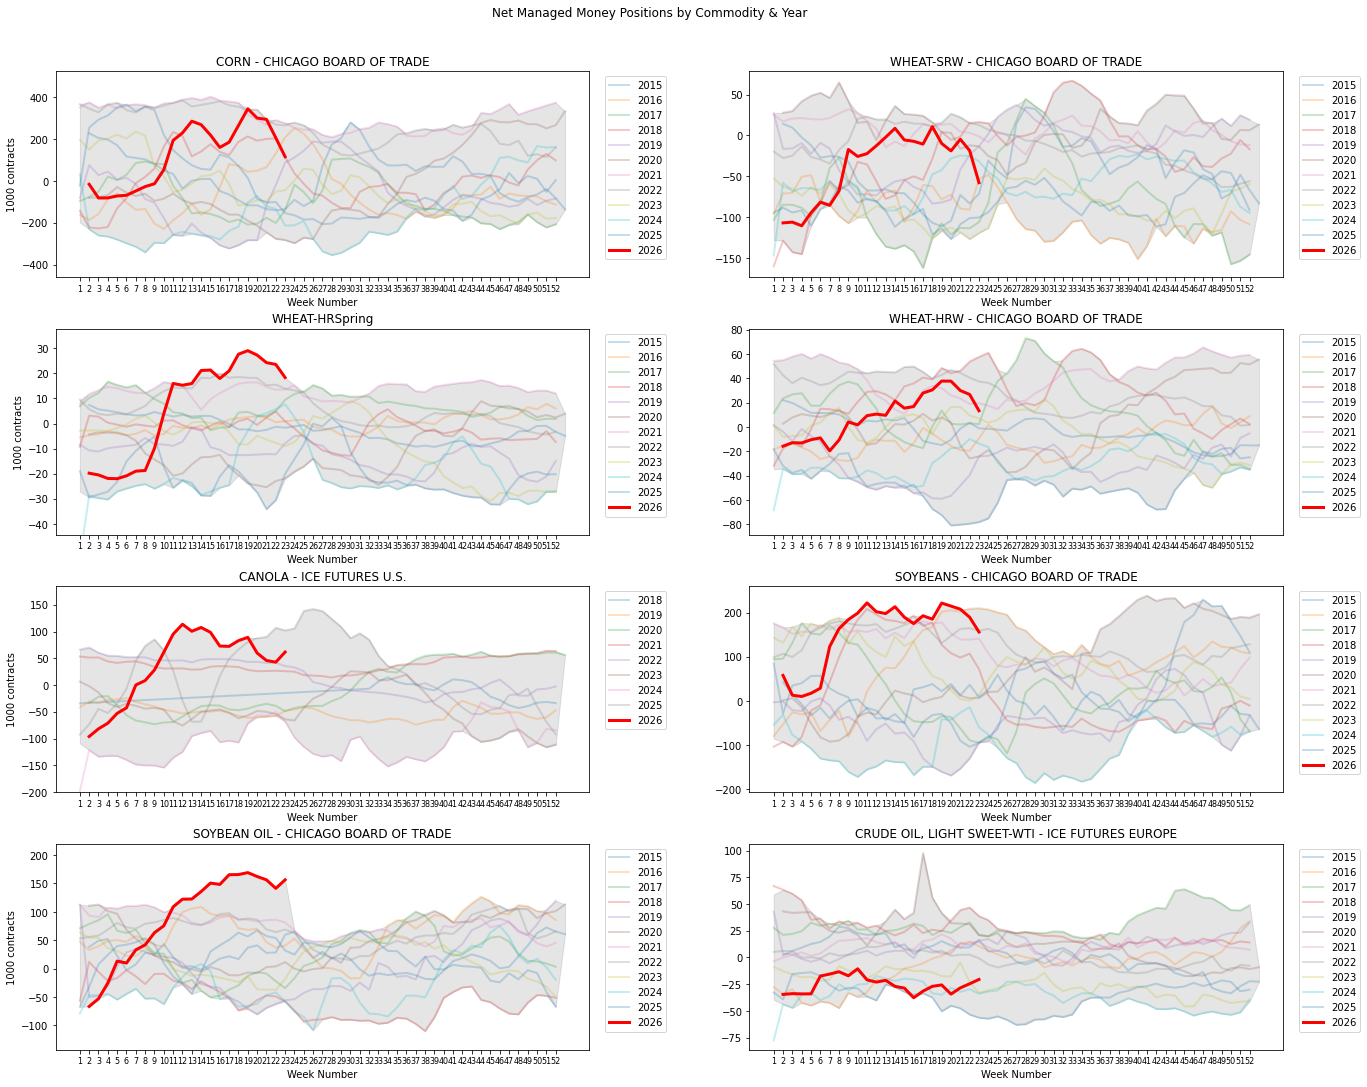

In [5]:
import datetime

# List of commodities to plot
commodities_to_plot = list(commodity_dict.keys())

# Create subplots for the desired number of plots
n_plots = len(commodities_to_plot)
n_cols = 2
n_rows = (n_plots + 1) // 2
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 18), sharex=False)
axs = axs.flatten()

for idx, commodity in enumerate(commodities_to_plot):
    commodity_df = combined_df[combined_df['Market_and_Exchange_Names'] == commodity]

    if commodity_df.empty or commodity_df['Net_Managed_Money_Positions'].isnull().all():
        # Skip if dataframe is empty or if there are no net managed money positions
        continue

    # create a new column with week number
    commodity_df.loc[:, 'Week_Number'] = pd.to_datetime(commodity_df['Report_Date_as_YYYY-MM-DD']).dt.isocalendar().week

    ax = axs[idx]
    year_groups = commodity_df.groupby('Year')

    # Plot shaded area between min and max values for each data point in any year
    data = commodity_df.groupby('Week_Number')['Net_Managed_Money_Positions'].agg(['min', 'max']) / 1000
    ax.fill_between(data.index, data['min'], data['max'], color='black', alpha=0.1)

    # Plot line for each year's data
    for year, year_data in year_groups:
        year_data = year_data.groupby('Week_Number')['Net_Managed_Money_Positions'].sum() / 1000
        #if year == datetime.datetime.now().year:
        if year == 2026:
            ax.plot(year_data, label=year, linewidth=3, linestyle='-', color='red')
        else:
            ax.plot(year_data, label=year, linewidth=2, alpha=0.25)

    # if idx // 2 == n_rows - 1:
    #     # Set x-axis label and ticks for the last row
    #     ax.set_xlabel('Week Number')
 

    if idx % 2 == 0:
        # Set y-axis label and scale for the first column
        ax.set_ylabel('1000 contracts')
        ax.set_ylim(commodity_df['Net_Managed_Money_Positions'].min() / 1000 * 1.3, commodity_df['Net_Managed_Money_Positions'].max() / 1000 * 1.3)

    # Set legend outside chart area and to the right
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
    fig.subplots_adjust(hspace=0.25, wspace=0.3)  # You can adjust the wspace value as needed

    # Set title for each chart
    ax.set_title(commodity)


# Add overall title
for ax in axs:
    ax.set_xlabel('Week Number')
    ax.set_xticks(range(1, 53))
    ax.set_xticklabels(range(1, 53), fontsize=8)
fig.suptitle('Net Managed Money Positions by Commodity & Year', y=0.93)

# Show the plot
plt.show()
